# Computer Vision in Python

[**TensorFlow**](https://www.tensorflow.org/)	A full open-source machine learning framework developed by Google for deep learning.

[**Keras**](https://keras.io/)	A high-level API that makes building and training models simpler.

---

**MobileNetV2**
* Image classification (e.g., dog breed)
* tensorflow.keras.applications
* `preprocess_input()` → scales to [-1, 1]
* Top prediction label + confidence score

**ImageNet Labels**
* Decodes class index to label
* `decode_predictions()`
* Used post-prediction
* Human-readable label (e.g., "golden_retriever")

See [Image Net Images](https://github.com/EliSchwartz/imagenet-sample-images)

---

# 1. Install dependencies

In [1]:
# I didn't need to run this cell in my Colab, but I'll include it here
#!pip install opencv-python-headless matplotlib tensorflow

# 2. Imports

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image

C:\Users\A1DN0ZZ\AppData\Roaming\Python\Python313\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.1.0)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(


# 3. Mount Drive and Load an image

In [3]:
# Mount drive to access image
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [9]:
# Troubleshooting:
# Check your file path to see if the JPG is present

import os
print(os.listdir('/content/drive/MyDrive/671 AI Solutions in the Cloud/671 Lecture Slides/671_03_CV/'))

['oscar-sutton-yihlaRCCvd4-unsplash.jpg', '671_Mod03_CV.gslides', 'CV in Python - Example.ipynb']


In [10]:
# Download the provided image from Brightspace and upload to a Google drive location

img_path = '/content/drive/My Drive/671 AI Solutions in the Cloud/671 Lecture Slides/671_03_CV/oscar-sutton-yihlaRCCvd4-unsplash.jpg'  # Replace with your image file and path
img = image.load_img(img_path, target_size=(224, 224))

# Accessed on May 14, 2025 from https://unsplash.com/s/photos/dog

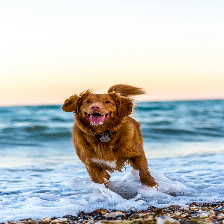

In [11]:
img

# 4. Preprocess the image

In [12]:
img_array = image.img_to_array(img)


## img_array

In [18]:
img_array

# NumPy array of RGB pixel values for the image, normalized to the [0, 1] range.

img_array_normal = img_array/255

array([[[249, 253, 254],
        [249, 253, 254],
        [252, 253, 255],
        ...,
        [240, 249, 248],
        [242, 250, 252],
        [240, 250, 251]],

       [[252, 254, 253],
        [251, 252, 254],
        [250, 251, 253],
        ...,
        [241, 249, 251],
        [241, 249, 251],
        [241, 249, 252]],

       [[252, 254, 253],
        [252, 254, 253],
        [252, 254, 253],
        ...,
        [241, 249, 251],
        [244, 249, 252],
        [243, 248, 251]],

       ...,

       [[180, 206, 241],
        [181, 206, 237],
        [172, 198, 231],
        ...,
        [112,  85,  74],
        [145, 122, 108],
        [231, 213, 193]],

       [[144, 173, 215],
        [177, 211, 246],
        [ 92,  85,  93],
        ...,
        [ 55,  31,  27],
        [123,  95,  84],
        [230, 206, 178]],

       [[ 50,  83, 114],
        [ 76,  87, 117],
        [ 44,  33,  39],
        ...,
        [ 26,  12,  11],
        [129, 107,  94],
        [128, 103,  83]]], dtype=uint8)
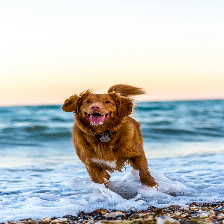

In [21]:
# Convert back to RGB values
img_255 = (img_array_normal * 255)
img_255

# To see the reconverted image
# img_255 = (img_255).astype('uint8')
# img_255
### The RGB color (243, 251, 253) is a very light, almost white color;
### pale and cool, slightly bluish due to the higher blue value.


## img_batch

Most Keras models expect image input shape to be in 4D: (batch_size, height, width, channels), even if you're just predicting one image.

(32, 64, 64, 3)

* 32: model processes 32 images at a time
* 64: height of image is 64 pixels
* 64: width of image is 64 pixels
* 3: RBG color channel

*Typical color channels:*
* 1 for grayscale images
* 3 for RGB images (red, green, blue)
* 4 for RGBA (includes alpha/transparency channel)

In [22]:
img_batch = np.expand_dims(img_array, axis=0)

img_batch

array([[[[249., 253., 254.],
         [249., 253., 254.],
         [252., 253., 255.],
         ...,
         [240., 249., 248.],
         [242., 250., 252.],
         [240., 250., 251.]],

        [[252., 254., 253.],
         [251., 252., 254.],
         [250., 251., 253.],
         ...,
         [241., 249., 251.],
         [241., 249., 251.],
         [241., 249., 252.]],

        [[252., 254., 253.],
         [252., 254., 253.],
         [252., 254., 253.],
         ...,
         [241., 249., 251.],
         [244., 249., 252.],
         [243., 248., 251.]],

        ...,

        [[180., 206., 241.],
         [181., 206., 237.],
         [172., 198., 231.],
         ...,
         [112.,  85.,  74.],
         [145., 122., 108.],
         [231., 213., 193.]],

        [[144., 173., 215.],
         [177., 211., 246.],
         [ 92.,  85.,  93.],
         ...,
         [ 55.,  31.,  27.],
         [123.,  95.,  84.],
         [230., 206., 178.]],

        [[ 50.,  83., 114.],
       

## img_preprocessed

Model-specific preprocessing (for MobileNetV2 in this case):

* Scales pixel values to [-1, 1] range.

* MobileNetV2 expects inputs normalized this way.

`preprocess_input()` → scales to [-1, 1]



In [23]:
img_preprocessed = preprocess_input(img_batch)

img_preprocessed.shape

#img_preprocessed

(1, 224, 224, 3)

## Summary of shapes

**img_array**        
shape: (224, 224, 3)	      

Raw pixel data from image

[0, 255] (or, if normalized, [0, 1])

**img_batch**	        
shape: (1, 224, 224, 3)	  

Adds batch dimension

[0, 255] or [0, 1]

**img_preprocessed**
shape: (1, 224, 224, 3)	  

Model-ready (normalized) input

Typically [-1, 1]

# 5. Load pre-trained model and predict

In [24]:
model = MobileNetV2(weights='imagenet')
preds = model.predict(img_preprocessed)
label = decode_predictions(preds, top=1)[0][0]

14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# 6. Display results

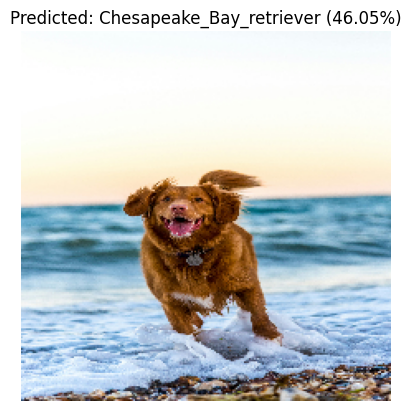

In [25]:
plt.imshow(img)
plt.axis('off')
plt.title(f"Predicted: {label[1]} ({label[2]*100:.2f}%)")
plt.show()

After predicting, the model gives a vector of 1000 probabilities.

`decode_predictions()` maps the top prediction to human labels (e.g., "Chesapeake_Bay_retriever", "golden_retriever").

## Other CV Possibilities (with Tool/Model)

* **Captioning**	"Dog running at the beach"	with BLIP, GPT-4V, OFA
* **Object Detection**	["dog", "ocean", "wave"] with YOLO, Detectron2, SSD
* **Scene Recognition**	"beach"	with Places365
* **Action Recognition**	"running"	with SlowFast, ViT action classifiers
* **Pose Estimation**	Coordinates of legs/head	with OpenPose, DeepLabCut

---

# See more labels

In [26]:
# See top 10 labels for our image
label = decode_predictions(preds, top=10)

print(label)

[[('n02099849', 'Chesapeake_Bay_retriever', np.float32(0.46053106)), ('n02099601', 'golden_retriever', np.float32(0.12165059)), ('n02100877', 'Irish_setter', np.float32(0.060654674)), ('n02093991', 'Irish_terrier', np.float32(0.053185213)), ('n02100583', 'vizsla', np.float32(0.01722464)), ('n02094114', 'Norfolk_terrier', np.float32(0.012774894)), ('n02102318', 'cocker_spaniel', np.float32(0.01186007)), ('n02093754', 'Border_terrier', np.float32(0.011670769)), ('n04409515', 'tennis_ball', np.float32(0.007917744)), ('n02099712', 'Labrador_retriever', np.float32(0.0074526523))]]


In [27]:
label[0]

[('n02099849', 'Chesapeake_Bay_retriever', np.float32(0.46053106)),
 ('n02099601', 'golden_retriever', np.float32(0.12165059)),
 ('n02100877', 'Irish_setter', np.float32(0.060654674)),
 ('n02093991', 'Irish_terrier', np.float32(0.053185213)),
 ('n02100583', 'vizsla', np.float32(0.01722464)),
 ('n02094114', 'Norfolk_terrier', np.float32(0.012774894)),
 ('n02102318', 'cocker_spaniel', np.float32(0.01186007)),
 ('n02093754', 'Border_terrier', np.float32(0.011670769)),
 ('n04409515', 'tennis_ball', np.float32(0.007917744)),
 ('n02099712', 'Labrador_retriever', np.float32(0.0074526523))]

In [28]:
df = pd.DataFrame(label[0], columns=['ID', 'Breed', 'Probability'])

# Round probabilities
df['Probability'] = df['Probability'].round(3)  # optional rounding

print(df)

          ID                     Breed  Probability
0  n02099849  Chesapeake_Bay_retriever        0.461
1  n02099601          golden_retriever        0.122
2  n02100877              Irish_setter        0.061
3  n02093991             Irish_terrier        0.053
4  n02100583                    vizsla        0.017
5  n02094114           Norfolk_terrier        0.013
6  n02102318            cocker_spaniel        0.012
7  n02093754            Border_terrier        0.012
8  n04409515               tennis_ball        0.008
9  n02099712        Labrador_retriever        0.007


## IDs?

When you use a **pre-trained** model like `MobileNet` and trained on `ImageNet`, the model outputs a 1,000-length vector of probabilities.

These probabilities correspond to the 1,000 ImageNet classes (for classes, see [here](https://deeplearning.cms.waikato.ac.nz/user-guide/class-maps/IMAGENET/))

Then we use `decode_predictions()` to make the classes human readable.

# Amazon Rekognition

Amazon Rekognition uses deep learning (most likely CNN) models trained on Amazon's own large, proprietary datasets, not `ImageNet`.

Real-world commercial applications (cost efficiency, speed, & scale)

Broad/general (dog, not golden retriever)



